In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import time
from itertools import combinations
from IPython.display import display

        Introducción

El presente trabajo se basa en el conjunto de datos del censo de vivienda de California de 1990, el cual recopila información demográfica, estructural y geoespacial a nivel de bloque censal. El conjunto de datos permite analizar las características urbanas y socioeconómicas de distintas zonas de California durante la década de los 90, integrando variables como la ubicación geográfica (longitud y latitud), la antigüedad de las construcciones, la población y los ingresos medios.

Objetivo Principal: Predecir de manera precisa el valor mediano de las viviendas (median_house_value) en un determinado sector o bloque censal.

Tipo de Problema: Aprendizaje supervisado de regresión con variable continua (en dólares estadounidenses).

        Descripción del conjunto de datos

Número de observaciones: 20,640 registros.

Número de variables: 10 variables en total, divididas en 9 variables predictoras y 1 variable objetivo.

Significado de la variable objetivo (median_house_value): Representa el valor mediano de la vivienda en un bloque censal específico, expresado en dólares estadounidenses (USD). (Presenta un límite superior o censura en exactamente $500,001, correspondientes a las viviendas que superaban dicho monto).

Tipos de variables:
9 variables de tipo numérico flotante (float64) correspondientes a coordenadas, mediciones estructurales y variables socioeconómicas.
1 variable de tipo categórico de texto (string) que describe la proximidad de la vivienda al mar (ocean_proximity).

-longitude (Numérica, float): Coordenada geográfica que indica la longitud; a menor valor, más al occidente se ubica el sector.

-latitude (Numérica, float): Coordenada geográfica que indica la latitud; a mayor valor, más al norte se ubica el sector.

-housing_median_age (Numérica, float): Antigüedad mediana de las construcciones en el bloque censal (en años).

-total_rooms (Numérica, float): Cantidad total de habitaciones registradas en el bloque. (Aunque corresponde a valores realmente enteros, se almacenan como decimales para facilitar y dar mayor precisión a los cálculos).

-total_bedrooms (Numérica, float): Cantidad total de dormitorios en el bloque censal (207 valores faltantes (equivalente al 1% de los registros de la columna).).

-population (Numérica, float): Cantidad total de residentes que habitan en el bloque.

-households (Numérica, float): Cantidad total de hogares o unidades familiares en el sector.

-median_income (Numérica, float): Ingreso mediano de los hogares en el bloque censal en decenas de miles de dólares 

-median_house_value (Numérica, float — Variable Objetivo): Valor mediano de la vivienda en el bloque (en USD).

-ocean_proximity (Categórica, string): Ubicación de la vivienda con respecto al mar u océano (ej. <1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY, ISLAND).

        Posibles limitaciones del conjunto de datos:

-Al tratarse de datos del censo estadounidense de 1990, no reflejan el mercado actual; pero son idóneas para el contexto académico del proyecto

-La variable total_bedrooms cuenta con 207 registros nulos, por lo que se necesita un análisis y una estrategia de imputación antes de entrenar cualquier modelo.

-Múltiples variables predictoras y la propia variable objetivo muestran distribuciones sesgadas y valores extremos o de amplio rango, lo cual se debe tener en cuenta al momento de definir las transformaciones o seleccionar algoritmos tolerantes a estas características.

        Estadísticas descriptivas:

Las variables numéricas reflejan rangos muy amplios; por ejemplo, la población por bloque va desde 3 hasta 35,682 habitantes, y el ingreso mediano (median_income) oscila entre 0.4999 y 15.0001 (en decenas de miles de dólares). Para la variable objetivo (median_house_value), se registra una media de $206,856 USD y una mediana de $179,700 USD, con un rango que parte desde los $14,999 USD hasta el tope de $500,001 USD.

        Distribución de la variable objetivo (median_house_value):

La distribución presenta una marcada asimetría a la derecha. La mayor parte de los valores de las viviendas se concentran entre los $100,000 y $250,000 USD.
Se identifica un límite superior muy marcado en $500,001 USD (con alrededor de 1,000 registros). Esto se debe al censo de 1990.

        Análisis de correlación entre variables numéricas:

median_income presenta la correlación lineal más alta y positiva con el valor de la vivienda (0.69), indicando que el ingreso del bloque censal es el predictor lineal individual más determinante. El resto de las variables numéricas muestran correlaciones lineales relativamente bajas o moderadas con el precio. Por lo que las relaciones no son lineales, lo que nos inclina al uso de modelos basados en árboles. Por otra parte, hay una alta  multicolinealidad entre las variables total_rooms, total_bedrooms, population y households, con coeficientes de correlación de Pearson muy altos entre sí.

        Análisis de las relaciones entre variables predictoras y la variable objetivo:

-Relación geográfica (Longitud y Latitud): Las representaciones geográficas de California demuestran que el valor mediano de la vivienda es considerablemente más alto en zonas costeras. 

-median_income vs. median_house_value: Muestra una relación positiva evidente, acompañada de heterocedasticidad a mayores niveles de ingreso y una concentración persistente de propiedades en el tope de $500,000 USD a lo largo de diversos tramos de ingresos.

-ocean_proximity vs. median_house_value: Los diagramas de caja (boxplots) confirman que las viviendas más costosas se concentran cerca del mar. Se observa que las zonas clasificadas como INLAND concentran las medianas de valor más bajas y un rango acotado, mientras que categorías como <1H OCEAN, NEAR BAY y NEAR OCEAN presentan distribuciones con los bigotes extendidos hacia los límites superior e inferior, además de una alta densidad de valores extremos en los límites superiores de precio.

Encabezado de los datos


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Estadísticas numéricas


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000



Estadísticas categóricas


,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136



Valores faltantes


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Estadísticas de median_house_value

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64
Mediana: 179700.0


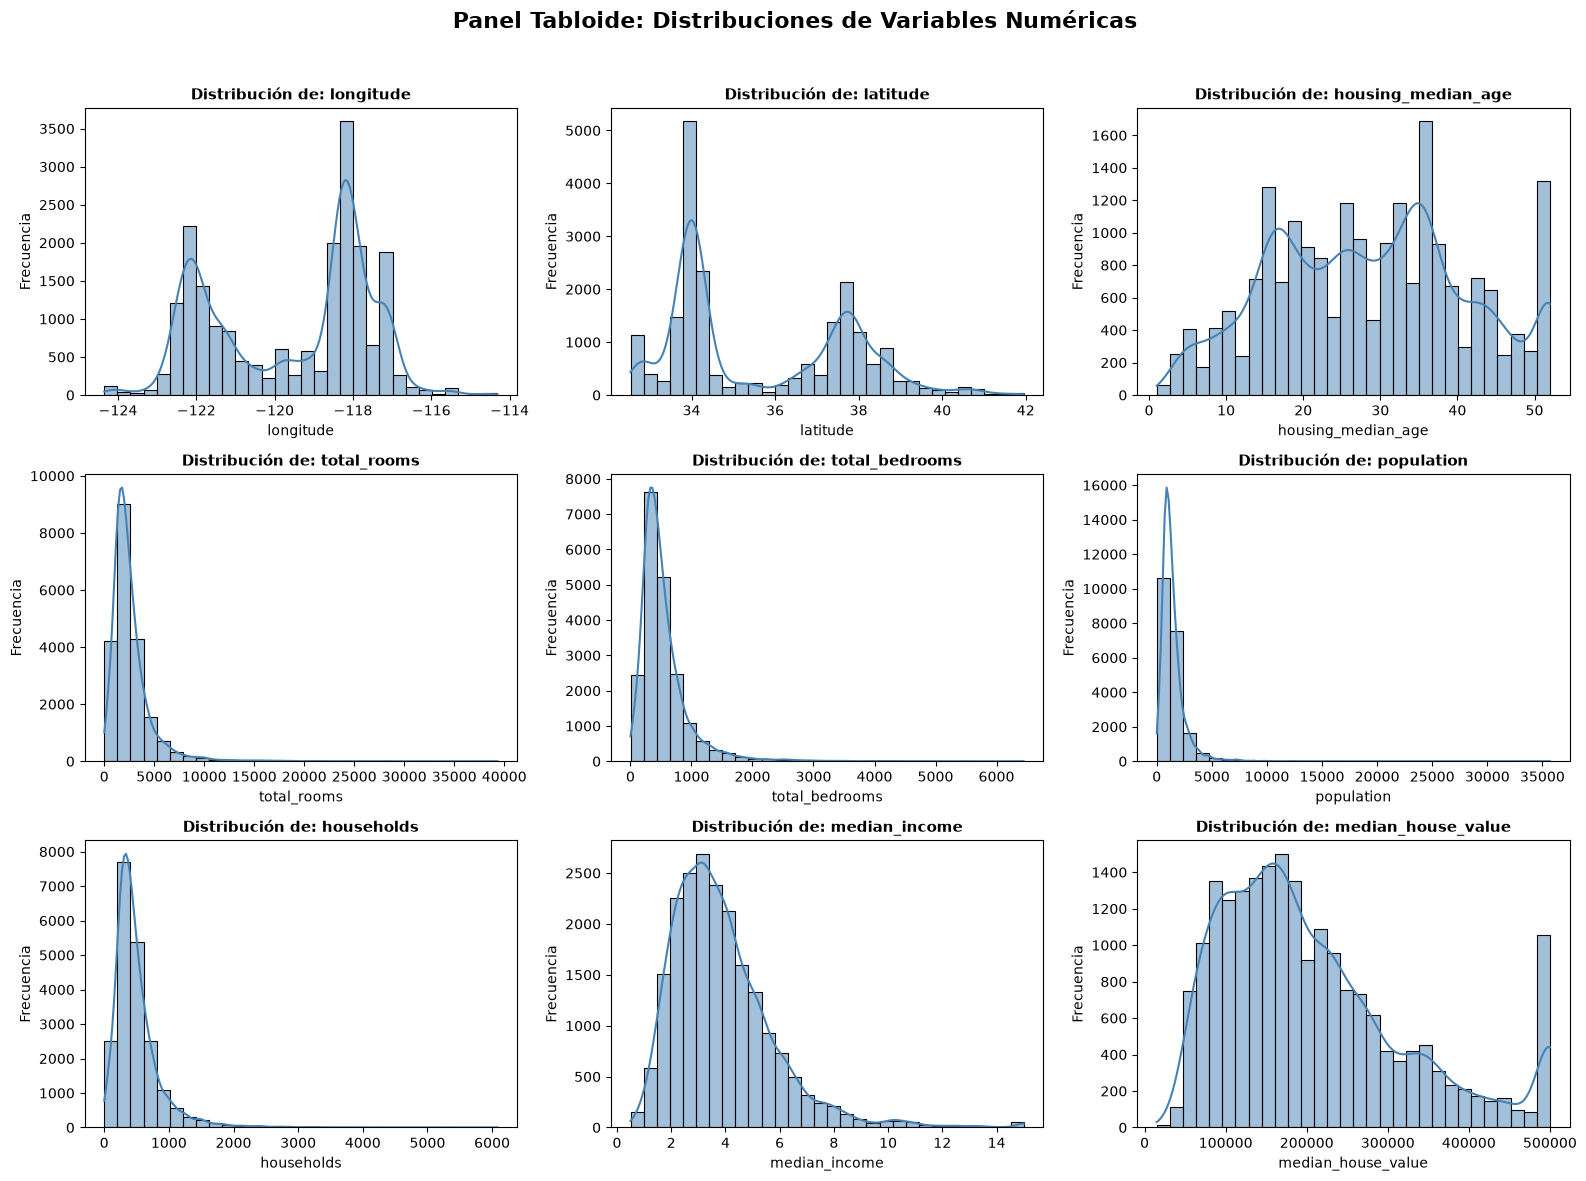

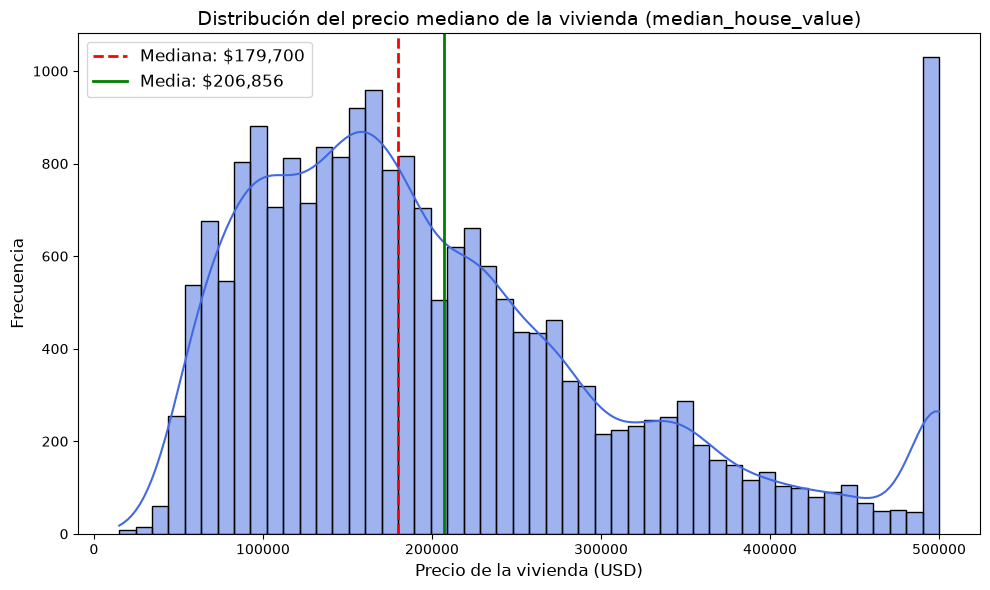

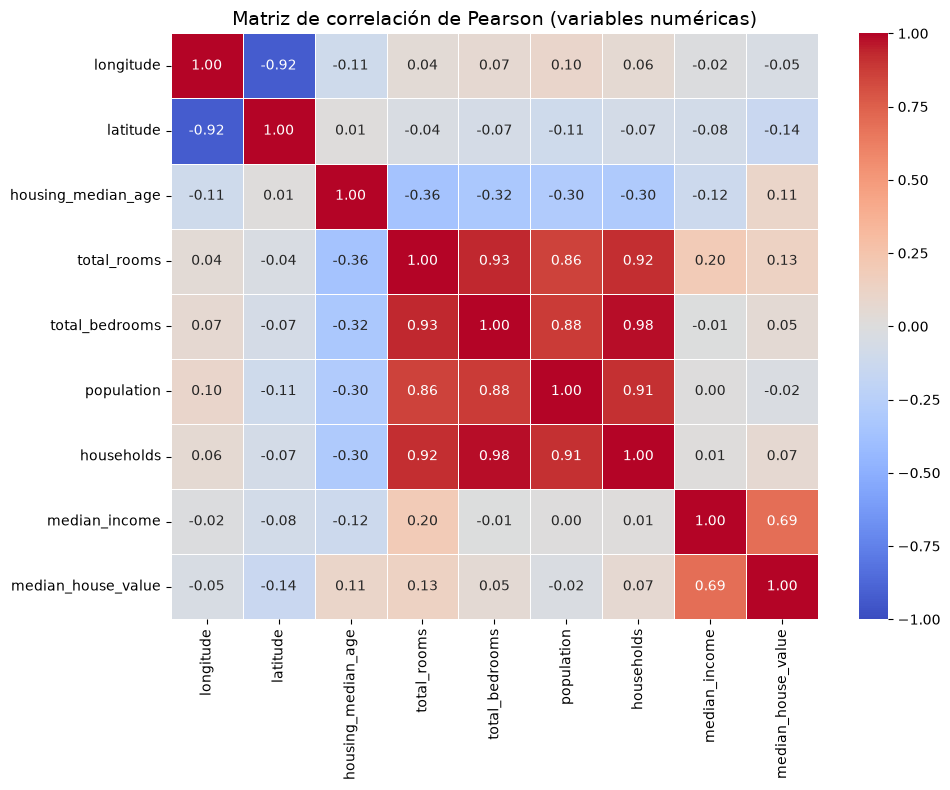

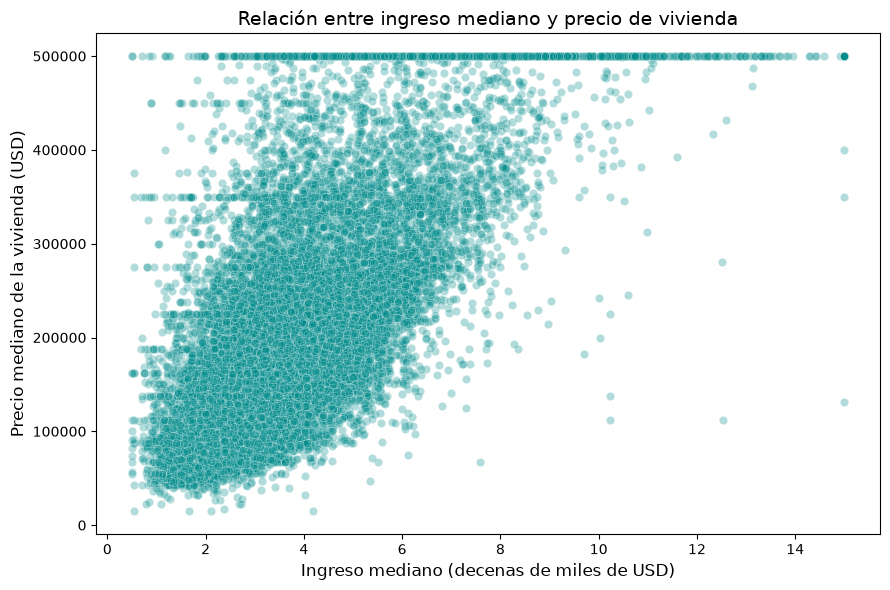

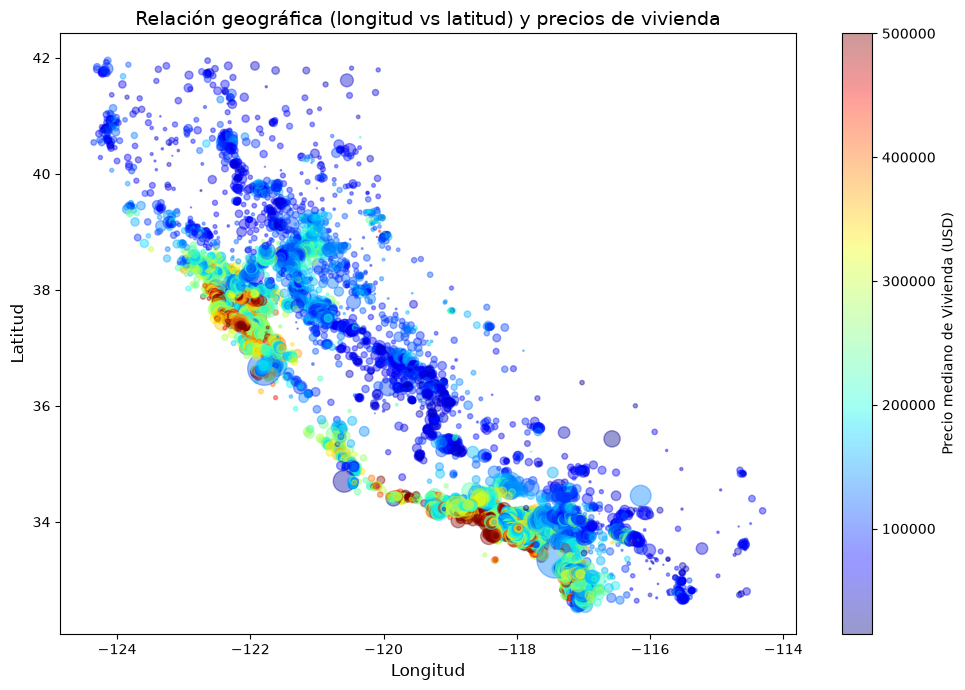

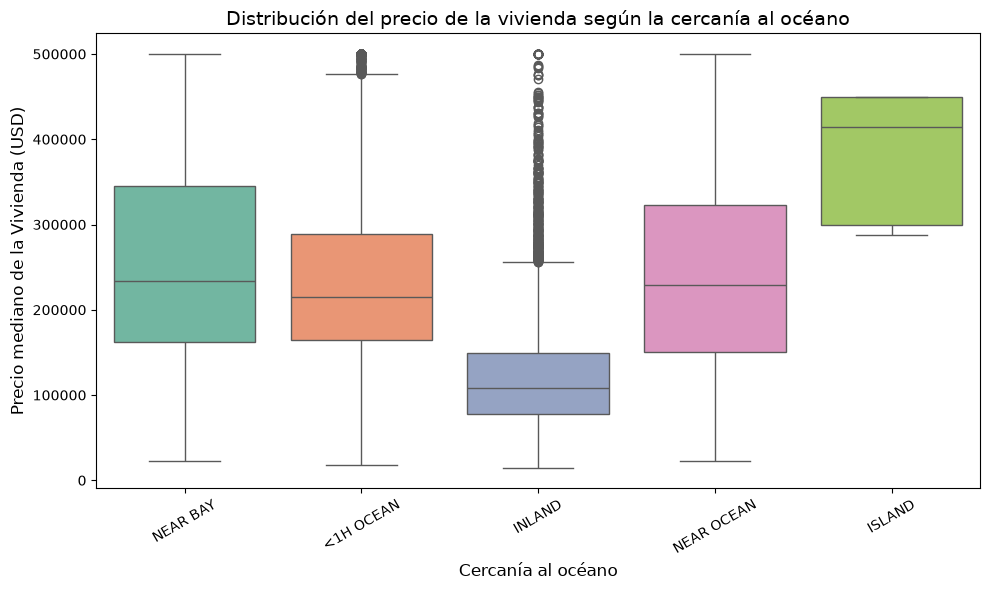

In [6]:
df = pd.read_csv("housingCopia.csv")

print("Encabezado de los datos")
display(df.head())

# Estadísticas numéricas
print("Estadísticas numéricas")
display(df.describe().T)

# Estadísticas descriptivas para la variable categórica (ocean_proximity)
print("\nEstadísticas categóricas")
display(df.describe(include=['str']))

# Conteo de valores nulos por columna
print("\nValores faltantes")
display(df.isnull().sum())

# Estadísticas de median house value en solitario
print("\nEstadísticas de median_house_value\n")
print(df['median_house_value'].describe())
print(f"Mediana: {df['median_house_value'].median()}")

# Definición previa de numeric_df para evitar errores de referencia antes de asignación
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_cols = numeric_df.columns

# Distribución de las Variables numéricas
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribución de: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)

plt.suptitle('Panel Tabloide: Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('numeric_distributions_grid.png', dpi=300)
plt.show()

# Distribución del valor mediano de la vivienda
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], kde=True, color='royalblue', bins=50)

plt.title('Distribución del precio mediano de la vivienda (median_house_value)', fontsize=14)
plt.xlabel('Precio de la vivienda (USD)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

plt.axvline(df['median_house_value'].median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: ${df["median_house_value"].median():,.0f}')
plt.axvline(df['median_house_value'].mean(), color='green', linestyle='-', linewidth=2, label=f'Media: ${df["median_house_value"].mean():,.0f}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Heatmap de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlación de Pearson (variables numéricas)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# Relación de ingresos con el precio
plt.figure(figsize=(9, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.3, color='darkcyan')
plt.title('Relación entre ingreso mediano y precio de vivienda', fontsize=14)
plt.xlabel('Ingreso mediano (decenas de miles de USD)', fontsize=12)
plt.ylabel('Precio mediano de la vivienda (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('income_vs_value.png', dpi=300)
plt.show()

# Relación geográfica y de precios (scatter plot Geográfico)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], alpha=0.4, s=df['population'] / 50, c=df['median_house_value'], cmap='jet')
plt.colorbar(scatter, label='Precio mediano de Vivienda (USD)')
plt.title('Relación geográfica (longitud vs latitud) y precios de vivienda', fontsize=14)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.tight_layout()
plt.savefig('geographic_relations.png', dpi=300)
plt.show()

# Relación de cercanía al océano y precio
plt.figure(figsize=(10, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, hue='ocean_proximity', palette='Set2',legend=False)
plt.title('Distribución del precio de la vivienda según la cercanía al océano', fontsize=14)
plt.xlabel('Cercanía al océano', fontsize=12)
plt.ylabel('Precio mediano de la Vivienda (USD)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('ocean_proximity_vs_value.png', dpi=300)
plt.show()